# Lesson 6: Advanced Tube Analysis - Condition Sweeps

Lesson 5 analyzed a tube under one fixed set of conditions. This notebook
sweeps **temperature**, **strand concentration**, and **salt (sodium)
concentration**, repeating `tube_analysis` at each point to build
melting-curve-style figures - and to define and locate the **melting
temperature** $T_m$ of a duplex as a property of the whole tube, not just of
one complex.

**By the end of this notebook you will be able to:**

- Sweep `Model(celsius=...)` to build a tube-level melting curve (yield vs.
  temperature) and locate $T_m$ (yield $= 0.5$).
- Explain - and demonstrate - why $T_m$ depends on **strand concentration**
  (mass action) as well as on temperature.
- Explain - and demonstrate - why $T_m$ depends on **sodium concentration**
  (electrostatic screening of the phosphate backbone).
- Distinguish this tube-level, yield-based melting curve from lesson 3's
  per-base-pair, $P_{ij}$-based melting curve.

**Prerequisites:** [`05_basic_tube_analysis.ipynb`](05_basic_tube_analysis.ipynb)
(`Tube`, `tube_analysis`, yield) and
[`03_probabilities.ipynb`](03_probabilities.ipynb) (temperature dependence of
$P_{ij}$).


## Introduction

Lesson 3 swept temperature and watched individual base-pair probabilities
$P_{ij}$ decay - a melting curve *within* one complex. Lesson 5 introduced
**yield**: the fraction of available strand that ends up in a target complex,
at fixed concentrations and temperature. Combining the two ideas gives a
**tube-level melting curve**: sweep temperature, and at each point re-run
`tube_analysis` to get the yield of the duplex.

This single idea - "re-run the tube analysis at each point of a parameter
sweep, and look at how yield changes" - generalizes directly to *any*
parameter that the `Model` or `Tube` depends on. Here we sweep three:

### Roadmap

1. **Temperature** at fixed concentration and salt: the classic melting
   curve, and how to read off $T_m$ from it.
2. **Strand concentration** at fixed salt: repeat the temperature sweep at
   three concentrations and see $T_m$ shift - higher concentration favors the
   bound state, raising $T_m$.
3. **Sodium concentration** at fixed strand concentration: repeat the
   temperature sweep at three salt levels - more salt screens the
   backbone's electrostatic repulsion, stabilizing the duplex and raising
   $T_m$.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")


def find_conc(conc_dict, *strands):
    '''Look up the equilibrium concentration of the complex containing exactly these strands.'''
    names = sorted(s.name for s in strands)
    for cx, val in conc_dict.items():
        if sorted(s.name for s in cx.strands) == names:
            return val
    return 0.0


def melting_temperature(temperatures, yields):
    '''Linearly interpolate the temperature where yield crosses 0.5.'''
    for i in range(len(temperatures) - 1):
        y0, y1 = yields[i], yields[i + 1]
        if y0 >= 0.5 >= y1:
            t0, t1 = temperatures[i], temperatures[i + 1]
            return t0 + (t1 - t0) * (y0 - 0.5) / (y0 - y1)
    return np.nan


a = Strand("GGGAAACCC", name="a")
b = Strand("GGGUUUCCC", name="b")
temperatures = list(range(20, 91, 10))


## Theory: melting temperature of a tube

For the `a+b` duplex from lesson 5, define the **yield** at temperature $T$,
concentration $C$ (with $[a] = [b] = C$), and sodium concentration $[\mathrm{Na}^+]$ as

$$
Y(T, C, [\mathrm{Na}^+]) = \frac{[(a{+}b)]_{\text{eq}}}{C},
$$

computed by `tube_analysis` with a `Model(celsius=T, sodium=[\mathrm{Na}^+])`
and `Tube(strands={a: C, b: C}, ...)`. The **melting temperature** $T_m$ is
the temperature where $Y = 0.5$ - by convention, "half the strands are paired
as the target duplex."

$Y$ depends on $T$ through $\Delta G^{\circ}(T)$ (as in lesson 3), but it also
depends on $C$ and $[\mathrm{Na}^+]$:

- **Concentration.** Binding is bimolecular: $a + b \rightleftharpoons (a{+}b)$.
  Increasing $C$ pushes the equilibrium toward the bound state (more
  collisions per unit time), so $Y$ at a fixed $T$ increases with $C$ - which
  means $T_m$ (the temperature needed to bring $Y$ back down to 0.5) also
  increases with $C$.
- **Salt.** RNA/DNA backbones are negatively charged; bringing two strands
  together to form a duplex means bringing those charges closer. Higher
  $[\mathrm{Na}^+]$ screens this repulsion (`Model(..., sodium=...)` feeds
  directly into NUPACK's salt-correction terms), stabilizing the duplex and
  raising $T_m$.

Both effects are why, in practice, oligo $T_m$ is always reported *together
with* the buffer conditions and concentration it was measured at.


## Worked example 1: a tube-level melting curve

Sweep temperature at $[a] = [b] = 1\ \mu\text{M}$ and $[\mathrm{Na}^+] = 1.0$ M
(the conditions used throughout lessons 1-5).


In [2]:
conc_baseline = 1e-6
sodium_baseline = 1.0

yields_baseline = []
for celsius in temperatures:
    model = Model(material="rna", celsius=celsius, sodium=sodium_baseline)
    tube = Tube(strands={a: conc_baseline, b: conc_baseline}, complexes=SetSpec(max_size=2), name="t")
    result = tube_analysis(tubes=[tube], model=model, compute=["pfunc"])
    conc = result[tube].complex_concentrations
    yields_baseline.append(find_conc(conc, a, b) / conc_baseline)

tm_baseline = melting_temperature(temperatures, yields_baseline)
print(f"T_m (1 uM, 1.0 M Na+) = {tm_baseline:.1f} deg C")

melt_df = pd.DataFrame({"Temperature (deg C)": temperatures, "Yield": yields_baseline})
display(melt_df)


T_m (1 uM, 1.0 M Na+) = 59.1 deg C


,Temperature (deg C),Yield
0,20,0.993727
1,30,0.981221
2,40,0.943703
3,50,0.822917
4,60,0.469323
5,70,0.070160
6,80,0.003814
7,90,0.000254


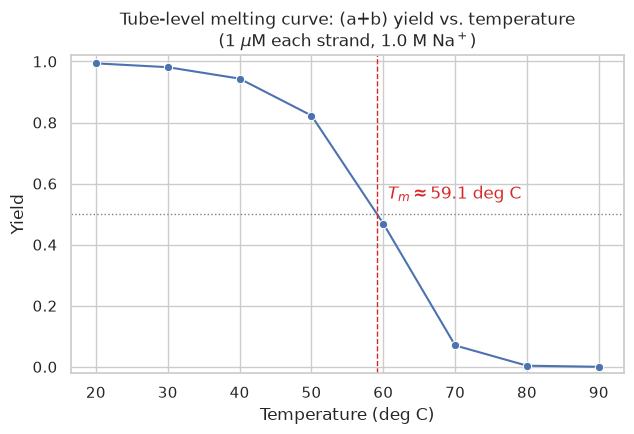

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.lineplot(data=melt_df, x="Temperature (deg C)", y="Yield", marker="o", ax=ax)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.axvline(tm_baseline, color="#d62728", linestyle="--", linewidth=1)
ax.text(tm_baseline + 1.5, 0.55, f"$T_m \\approx {tm_baseline:.1f}$ deg C", color="#d62728")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Tube-level melting curve: (a+b) yield vs. temperature\n(1 $\\mu$M each strand, 1.0 M Na$^+$)")
fig.tight_layout()
plt.show()


**Interpretation.** This is an S-shaped melting curve, the tube-level analog
of lesson 3's per-pair curves. At low temperature, essentially all of `a` and
`b` are bound as the duplex ($Y \approx 1$); above $\sim$60 deg C the duplex
rapidly dissociates. $T_m \approx 59$ deg C is where exactly half of the
strands are paired. Unlike lesson 3's curves (which tracked *individual base
pairs* and showed different pairs melting at different rates), this curve
tracks the *whole complex* - it's the quantity you'd actually measure with a
UV-absorbance melting experiment.


## Worked example 2: $T_m$ depends on concentration

Repeat the same sweep at two more concentrations: 1 nM (1000x more dilute)
and 10 $\mu$M (10x more concentrated), holding $[\mathrm{Na}^+] = 1.0$ M
fixed.


In [4]:
concentrations = [1e-9, 1e-6, 1e-5]
conc_labels = ["1 nM", "1 $\\mu$M", "10 $\\mu$M"]

conc_results = {}
for c, label in zip(concentrations, conc_labels):
    if c == conc_baseline:
        conc_results[label] = yields_baseline
        continue
    ys = []
    for celsius in temperatures:
        model = Model(material="rna", celsius=celsius, sodium=sodium_baseline)
        tube = Tube(strands={a: c, b: c}, complexes=SetSpec(max_size=2), name="t")
        result = tube_analysis(tubes=[tube], model=model, compute=["pfunc"])
        conc = result[tube].complex_concentrations
        ys.append(find_conc(conc, a, b) / c)
    conc_results[label] = ys

tm_by_conc = {label: melting_temperature(temperatures, ys) for label, ys in conc_results.items()}
display(pd.Series(tm_by_conc, name="T_m (deg C)"))


1 nM         31.494973
1 $\mu$M     59.132425
10 $\mu$M    66.483530
Name: T_m (deg C), dtype: float64

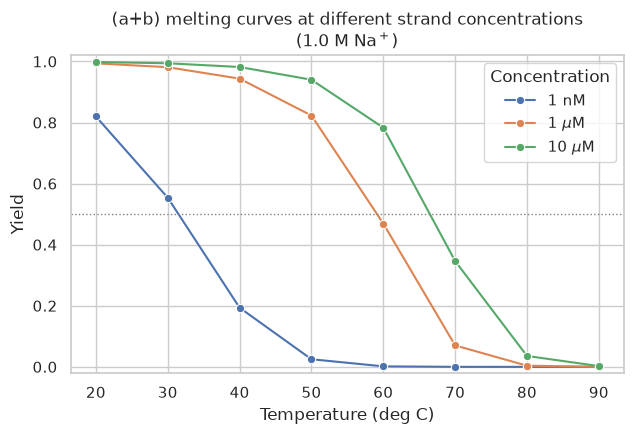

In [5]:
conc_long = pd.DataFrame(conc_results, index=temperatures).reset_index().melt(
    id_vars="index", var_name="Concentration", value_name="Yield"
).rename(columns={"index": "Temperature (deg C)"})

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.lineplot(data=conc_long, x="Temperature (deg C)", y="Yield", hue="Concentration", marker="o", ax=ax)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_ylim(-0.02, 1.02)
ax.set_title("(a+b) melting curves at different strand concentrations\n(1.0 M Na$^+$)")
fig.tight_layout()
plt.show()


**Interpretation.** All three curves have the same S-shape, but shifted
along the temperature axis: the 1 nM curve melts around $T_m \approx 31$ deg
C, the 1 $\mu$M curve (worked example 1) around 59 deg C, and the 10 $\mu$M
curve around 66 deg C. A 1000x increase in concentration (1 nM to 1
$\mu$M) shifts $T_m$ by about 28 deg C - **a "melting temperature" is only
meaningful together with the concentration it was measured at.**


## Worked example 3: $T_m$ depends on salt concentration

Now hold $[a] = [b] = 1\ \mu\text{M}$ fixed and sweep $[\mathrm{Na}^+]$
instead: 0.05 M (low salt), 0.5 M, and 1.0 M (worked example 1).


In [6]:
sodium_concentrations = [0.05, 0.5, 1.0]
sodium_labels = ["0.05 M Na$^+$", "0.5 M Na$^+$", "1.0 M Na$^+$"]

sodium_results = {}
for na, label in zip(sodium_concentrations, sodium_labels):
    if na == sodium_baseline:
        sodium_results[label] = yields_baseline
        continue
    ys = []
    for celsius in temperatures:
        model = Model(material="rna", celsius=celsius, sodium=na)
        tube = Tube(strands={a: conc_baseline, b: conc_baseline}, complexes=SetSpec(max_size=2), name="t")
        result = tube_analysis(tubes=[tube], model=model, compute=["pfunc"])
        conc = result[tube].complex_concentrations
        ys.append(find_conc(conc, a, b) / conc_baseline)
    sodium_results[label] = ys

tm_by_sodium = {label: melting_temperature(temperatures, ys) for label, ys in sodium_results.items()}
display(pd.Series(tm_by_sodium, name="T_m (deg C)"))


0.05 M Na$^+$    46.971615
0.5 M Na$^+$     55.983564
1.0 M Na$^+$     59.132425
Name: T_m (deg C), dtype: float64

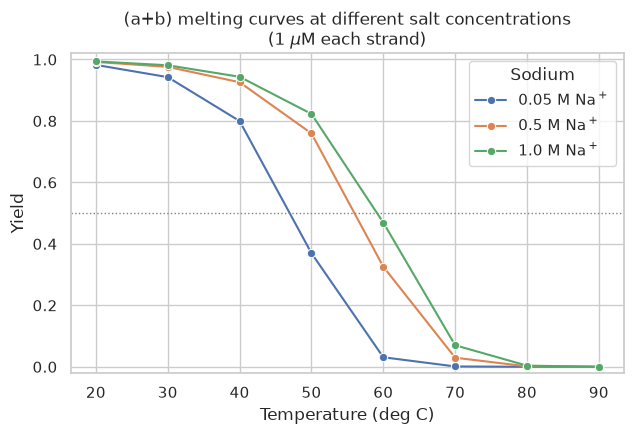

In [7]:
sodium_long = pd.DataFrame(sodium_results, index=temperatures).reset_index().melt(
    id_vars="index", var_name="Sodium", value_name="Yield"
).rename(columns={"index": "Temperature (deg C)"})

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.lineplot(data=sodium_long, x="Temperature (deg C)", y="Yield", hue="Sodium", marker="o", ax=ax)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_ylim(-0.02, 1.02)
ax.set_title("(a+b) melting curves at different salt concentrations\n(1 $\\mu$M each strand)")
fig.tight_layout()
plt.show()


**Interpretation.** Lower salt destabilizes the duplex: at 0.05 M Na$^+$,
$T_m \approx 47$ deg C, rising to $\approx 56$ deg C at 0.5 M and
$\approx 59$ deg C at 1.0 M (worked example 1). The effect is sub-linear -
going from 0.05 to 0.5 M (10x) shifts $T_m$ by about 9 deg C, while 0.5 to
1.0 M (2x) shifts it by only about 3 deg C - consistent with electrostatic
screening having diminishing returns as $[\mathrm{Na}^+]$ increases.


## Best practices and common pitfalls

- **A sweep is just a loop over `Model`/`Tube` construction.** There's no
  special "sweep" API - build a fresh `Model` (and, if concentrations change,
  a fresh `Tube`) for each point and call `tube_analysis` again. This is the
  same pattern as lesson 3's temperature loop, generalized to any parameter.
- **$T_m$ from a coarse grid is an approximation.** The linear interpolation
  used here (`melting_temperature`) is only as good as the grid spacing - for
  a publication-quality $T_m$, use a finer grid (e.g. 1-2 deg C steps) near
  the crossing point.
- **Don't conflate the lesson-3 melting curve with this one.** Lesson 3
  plotted $P_{ij}(T)$ for *fixed* concentration implicitly baked into a
  single-complex `complex_analysis` (no concentration dependence at all -
  `pfunc`/`pairs` describe one complex's internal ensemble). This lesson's
  $Y(T)$ is a *tube* quantity and explicitly depends on concentration; the two
  are related but answer different questions ("how does this complex's
  internal structure change with $T$?" vs. "what fraction of my strands are in
  this complex at all?").
- **Sodium isn't the only salt NUPACK models.** `Model(..., magnesium=...)`
  is also available for divalent cations, which have a much stronger
  stabilizing effect per mole than sodium - not covered here, but the same
  sweep pattern applies.


## Summary

In this notebook you:

1. Built a **tube-level melting curve** by sweeping temperature and re-running
   `tube_analysis` at each point, and located $T_m$ where yield $= 0.5$.
2. Swept **strand concentration** and saw $T_m$ shift by tens of degrees
   across a 1000x concentration range - a direct consequence of mass action.
3. Swept **sodium concentration** and saw $T_m$ rise (with diminishing
   returns) as electrostatic screening increases.

This completes the "analysis" half of the tutorial series (lessons 1-6): you
can now characterize a single complex's structure, probabilities, and defect,
and a tube's equilibrium composition and how it responds to conditions.

**Next:** [`07_intro_design.ipynb`](07_intro_design.ipynb) turns the problem
around: instead of analyzing a *given* sequence, you'll specify a *target*
structure and let NUPACK search for sequences that achieve it - using the
defect from lesson 4 as the objective being minimized.


## Exercises

1. The temperature grid here is 10 deg C. Add points at 55 and 65 deg C to
   the baseline (1 $\mu$M, 1.0 M Na$^+$) sweep and recompute $T_m$ - how much
   does the estimate change?
2. Worked example 2 used a 1000x concentration range (1 nM to 10 $\mu$M).
   Estimate $T_m$ at 1 pM (1e-12 M) by extending the temperature sweep to
   lower temperatures (e.g. down to 0 deg C) - does $Y$ ever reach 0.5 in the
   biologically-relevant 0-100 deg C range?
